# Piloto 2026 — validación final anidada del modelo de aromas

## tl;dr

**Veredicto:** `NO_VALID_MODEL`.  
**Modelo seleccionado:** `None`.

La comparación final contiene: recuperación constante, recuperación dependiente de etanol y esta última con un reservorio de línea que conserva masa. La calibración se pondera de acuerdo con el NRMSE del gate y se valida dejando fuera un reactor completo.

## Contrato de interpretación

- Producción: dos rendimientos ligados al consumo de azúcar; no se agrega aquí otro estado de pulso porque no fue transferible en la prueba anterior.
- Pérdida: partición Morakul/Mouret dependiente de etanol y temperatura, forzada por el rCO₂ validado.
- Observación: fracción efectiva de recuperación dependiente de etanol.
- Memoria: inventario de línea de primer orden; su τ sólo es físico si coincide con una medición de residencia.
- Validación: interna retrospectiva; una campaña prospectiva sellada sigue siendo obligatoria.

In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display, Image

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'fermentation_model').exists():
    ROOT = ROOT.parent
if not (ROOT / 'fermentation_model').exists():
    raise RuntimeError('Execute from the repository or a descendant directory')
sys.path.insert(0, str(ROOT / 'fermentation_model'))
from pilot_2026 import run_aroma_final_nested_validation_2026 as analysis
result = analysis.load_results() if os.environ.get('PILOT_AROMA_REUSE_RESULTS') == '1' else analysis.run_analysis()
print('Veredicto:', result['gate']['verdict'])
print('Modelo seleccionado:', result['gate']['selected_model'])
print('Mejor diagnóstico:', result['gate']['diagnostic_best_model'])

Veredicto: NO_VALID_MODEL
Modelo seleccionado: None
Mejor diagnóstico: ethanol_capture_plus_line_reservoir


## Calidad y límite de reproducibilidad

,species,n_directional_pairs,rmse_ug,observed_mean_ug,replicate_as_predictor_nrmse,median_absolute_fold_difference
0,ethyl_octanoate,16,487.8058,462.3358,1.0551,3.0953
1,isoamyl_acetate,10,1942.9876,2004.4622,0.9693,1.6795


,experiment_id,sample_id,time_h,analytes_compared,median_fold,maximum_fold,flagged_26211_P12
0,26210,26210-P-05,48.0,4,3.957,7.448,False
1,26211,26211-P-12,144.0,6,3.941,4.785,True
2,26158,26158-P-05,50.0,4,3.152,9.289,False
3,26211,26211-P-05,48.0,4,2.053,5.860,False
4,26157,26157-P-05,50.0,4,1.903,7.385,False
5,26212,26212-P-06,64.0,6,1.835,2.638,False
6,26157,26157-P-08,91.0,6,1.510,1.670,False
7,26211,26211-P-08,88.0,5,1.435,1.717,False
8,26159,26159-P-09,115.0,5,1.396,1.596,False
9,26212,26212-P-08,88.0,6,1.180,1.401,False


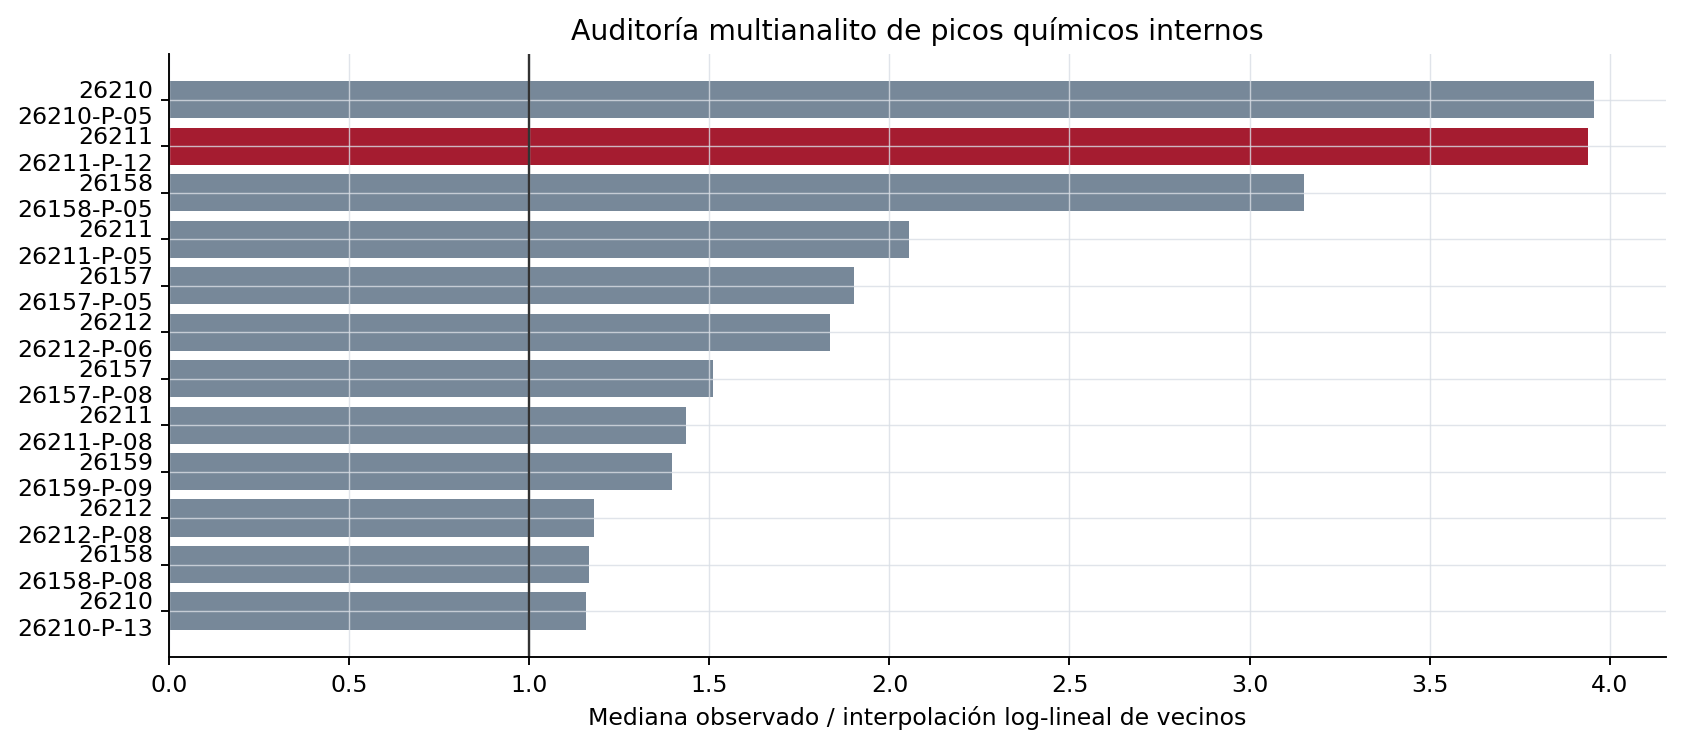

In [2]:
display(result['repeatability'].round(4))
display(result['anomaly_summary'].head(10).round(3))
display(Image(filename=analysis.FIGURE_DIR / '01_sample_anomaly_audit.png'))

## Validación cruzada y estabilidad

,analysis_policy,model_variant,species,domain,n_observed_scored,observed_mean,rmse,nrmse_over_mean,mae,bias
0,exclude_26211_P12_wine,ethanol_capture_plus_line_reservoir,ethyl_octanoate,wine,32,70.3716,19.4204,0.2760,14.9462,-1.7162
1,exclude_26211_P12_wine,ethanol_capture_plus_line_reservoir,isoamyl_acetate,wine,32,973.3165,418.6330,0.4301,346.5746,-59.6270
2,exclude_26211_P12_wine,ethanol_dependent_capture_efficiency,ethyl_octanoate,wine,32,70.3716,19.4024,0.2757,14.9114,-1.7639
3,exclude_26211_P12_wine,ethanol_dependent_capture_efficiency,isoamyl_acetate,wine,32,973.3165,418.6439,0.4301,346.5904,-59.5898
4,exclude_26211_P12_wine,fitted_capture_efficiency,ethyl_octanoate,wine,32,70.3716,19.1100,0.2716,14.8159,-2.4380
5,exclude_26211_P12_wine,fitted_capture_efficiency,isoamyl_acetate,wine,32,973.3165,415.4200,0.4268,342.3300,-62.9315
6,primary,ethanol_capture_plus_line_reservoir,ethyl_octanoate,wine,33,75.0941,31.5972,0.4208,18.7873,-5.2041
7,primary,ethanol_capture_plus_line_reservoir,isoamyl_acetate,wine,33,1026.5980,487.9528,0.4753,381.5577,-80.6540
8,primary,ethanol_dependent_capture_efficiency,ethyl_octanoate,wine,33,75.0941,31.5863,0.4206,18.7529,-5.2398
9,primary,ethanol_dependent_capture_efficiency,isoamyl_acetate,wine,33,1026.5980,488.0087,0.4754,381.5627,-80.6519


,model_variant,species,baseline_condensate_nrmse,candidate_condensate_nrmse,condensate_nrmse_reduction_fraction,condensate_reduction_pass,baseline_wine_nrmse,candidate_wine_nrmse,wine_nrmse_degradation_fraction,wine_guardrail_pass,fraction_runs_lower_condensate_squared_error,run_consistency_pass
0,ethanol_dependent_capture_efficiency,ethyl_octanoate,1.5507,1.1940,0.2300,False,0.4164,0.4206,0.0102,True,0.8,True
1,ethanol_dependent_capture_efficiency,isoamyl_acetate,1.3228,0.9971,0.2462,False,0.4721,0.4754,0.0069,True,1.0,True
2,ethanol_capture_plus_line_reservoir,ethyl_octanoate,1.5507,1.1876,0.2341,False,0.4164,0.4208,0.0105,True,0.8,True
3,ethanol_capture_plus_line_reservoir,isoamyl_acetate,1.3228,0.9853,0.2551,False,0.4721,0.4753,0.0068,True,1.0,True


,model_variant,species,parameter,folds,median_estimate,minimum_estimate,maximum_estimate,log_standard_deviation,active_bound_fraction
0,ethanol_capture_plus_line_reservoir,ethyl_octanoate,capture_efficiency_fraction,6,0.03866,0.02544,0.05094,0.23407,0.0
1,ethanol_capture_plus_line_reservoir,ethyl_octanoate,ethanol_capture_multiplier_per_10_g_l,6,2.32057,1.85881,2.47687,0.10557,0.0
2,ethanol_capture_plus_line_reservoir,ethyl_octanoate,formation_growth_ug_per_g_sugar,6,0.94906,0.54230,1.62161,0.41750,0.0
3,ethanol_capture_plus_line_reservoir,ethyl_octanoate,formation_stationary_ug_per_g_sugar,6,0.75694,0.69651,0.82941,0.06823,0.0
4,ethanol_capture_plus_line_reservoir,ethyl_octanoate,line_reservoir_tau_h,6,5.13766,3.18642,6.49545,0.27650,0.0
5,ethanol_capture_plus_line_reservoir,isoamyl_acetate,capture_efficiency_fraction,6,0.01530,0.00951,0.02021,0.27050,0.0
6,ethanol_capture_plus_line_reservoir,isoamyl_acetate,ethanol_capture_multiplier_per_10_g_l,6,2.27050,1.90879,2.42526,0.08916,0.0
7,ethanol_capture_plus_line_reservoir,isoamyl_acetate,formation_growth_ug_per_g_sugar,6,8.40816,2.08145,12.85553,0.83801,0.0
8,ethanol_capture_plus_line_reservoir,isoamyl_acetate,formation_stationary_ug_per_g_sugar,6,9.67745,8.15684,11.47748,0.14354,0.0
9,ethanol_capture_plus_line_reservoir,isoamyl_acetate,line_reservoir_tau_h,6,5.63836,4.10732,6.85158,0.20981,0.0


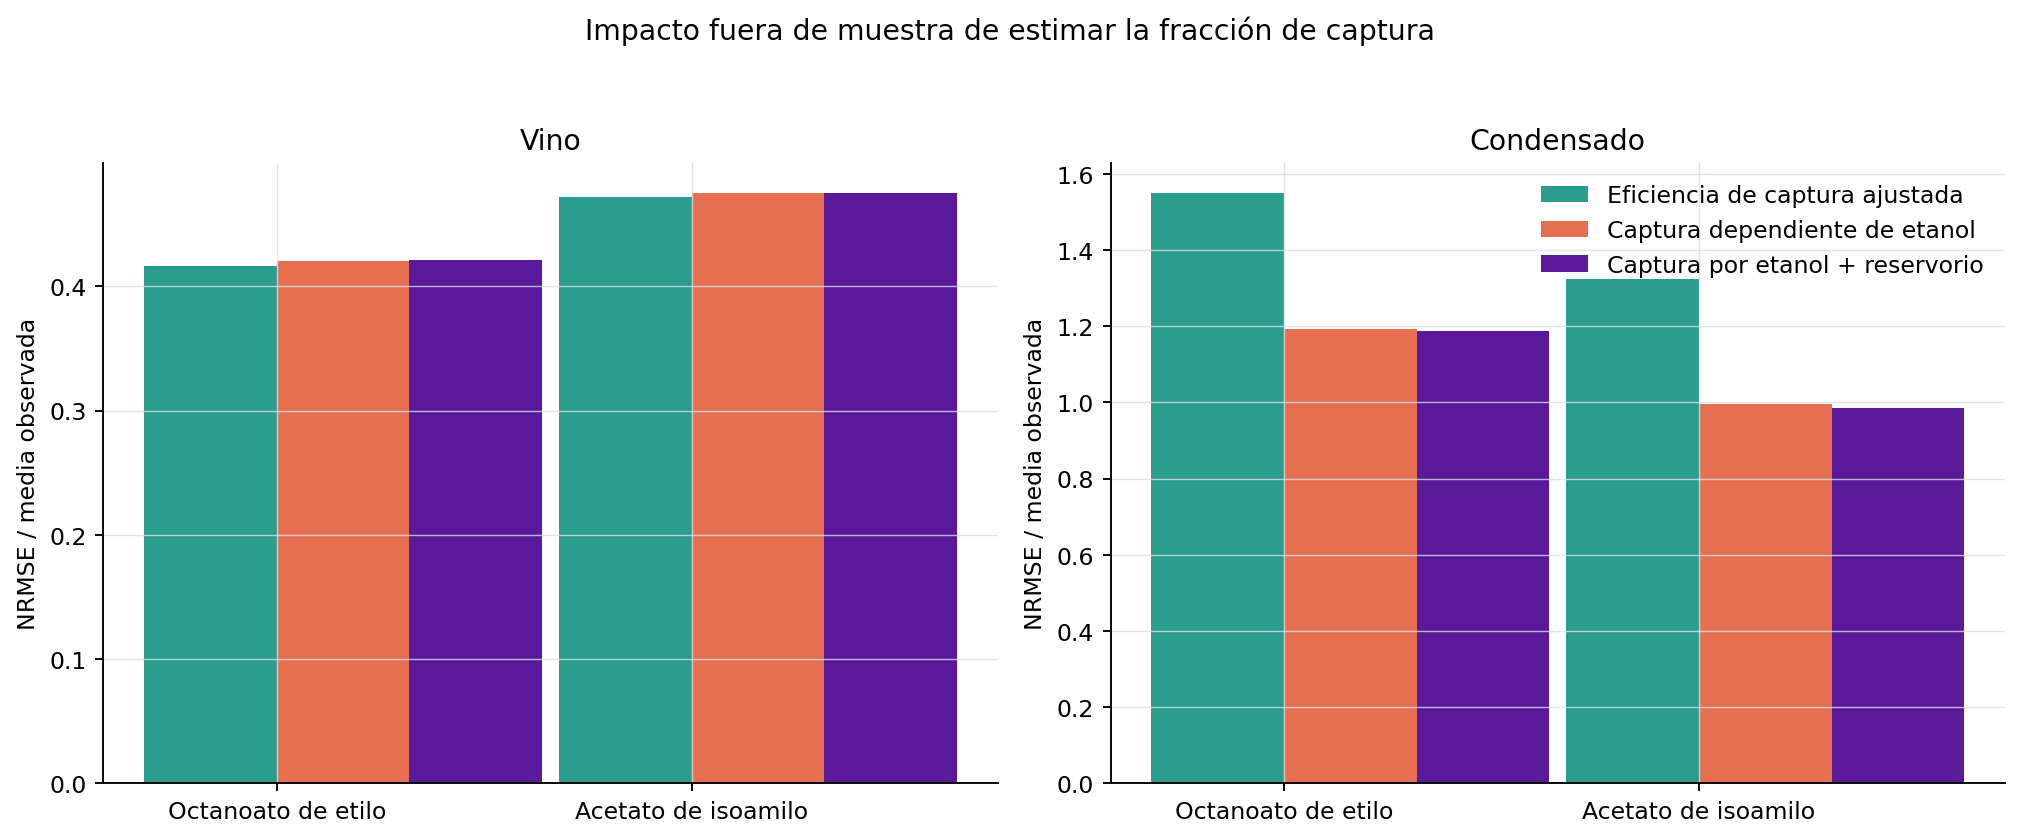

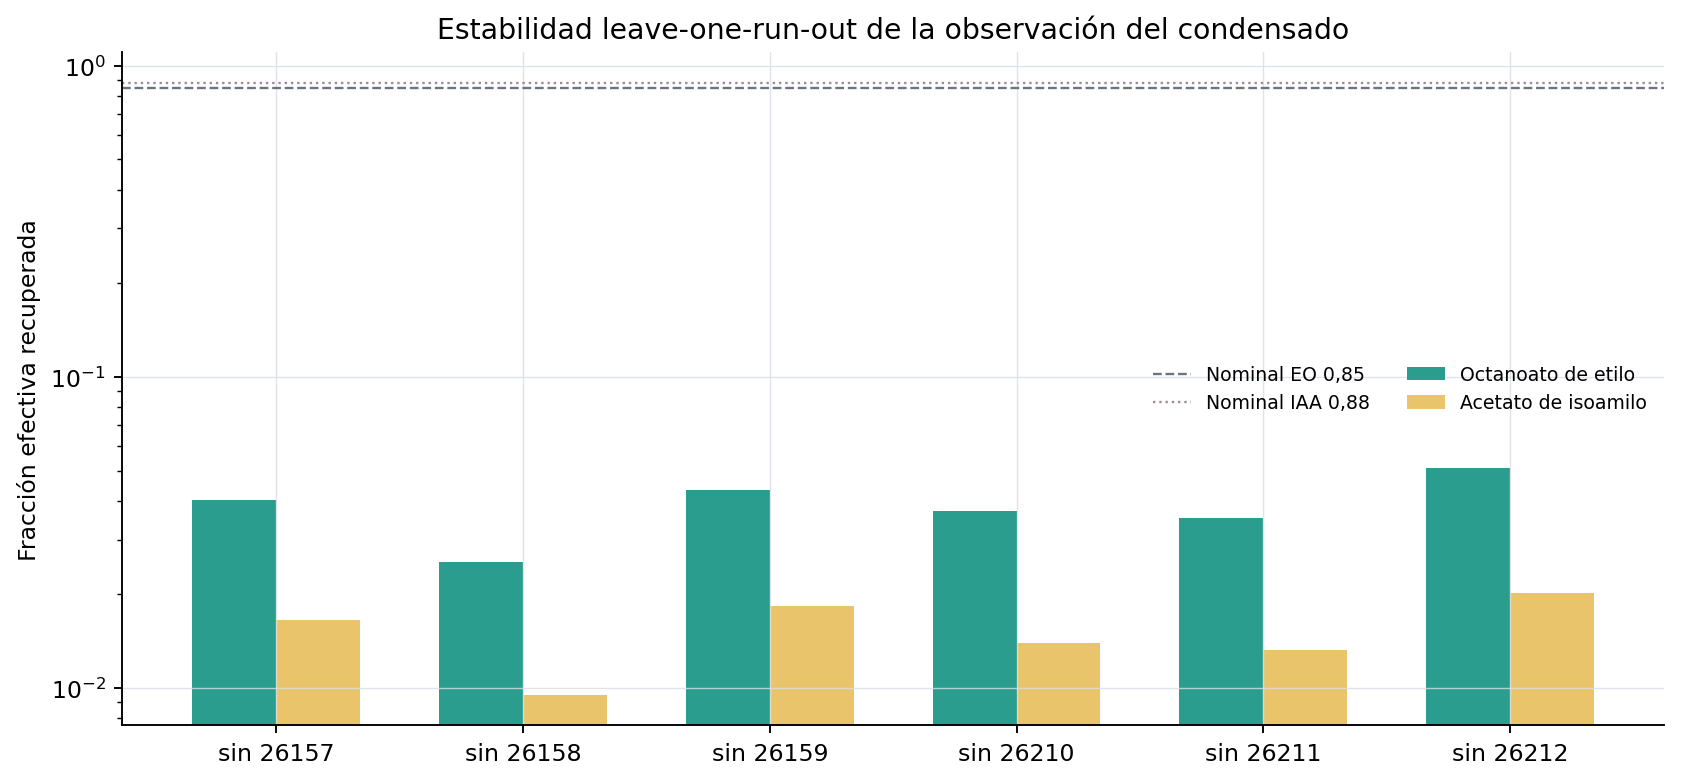

In [3]:
display(result['metrics'].round(4))
display(result['comparison'].round(4))
display(result['stability'].round(5))
display(Image(filename=analysis.FIGURE_DIR / '02_capture_efficiency_loro_nrmse.png'))
display(Image(filename=analysis.FIGURE_DIR / '07_capture_efficiency_by_fold.png'))

## Forzantes y curvas finales

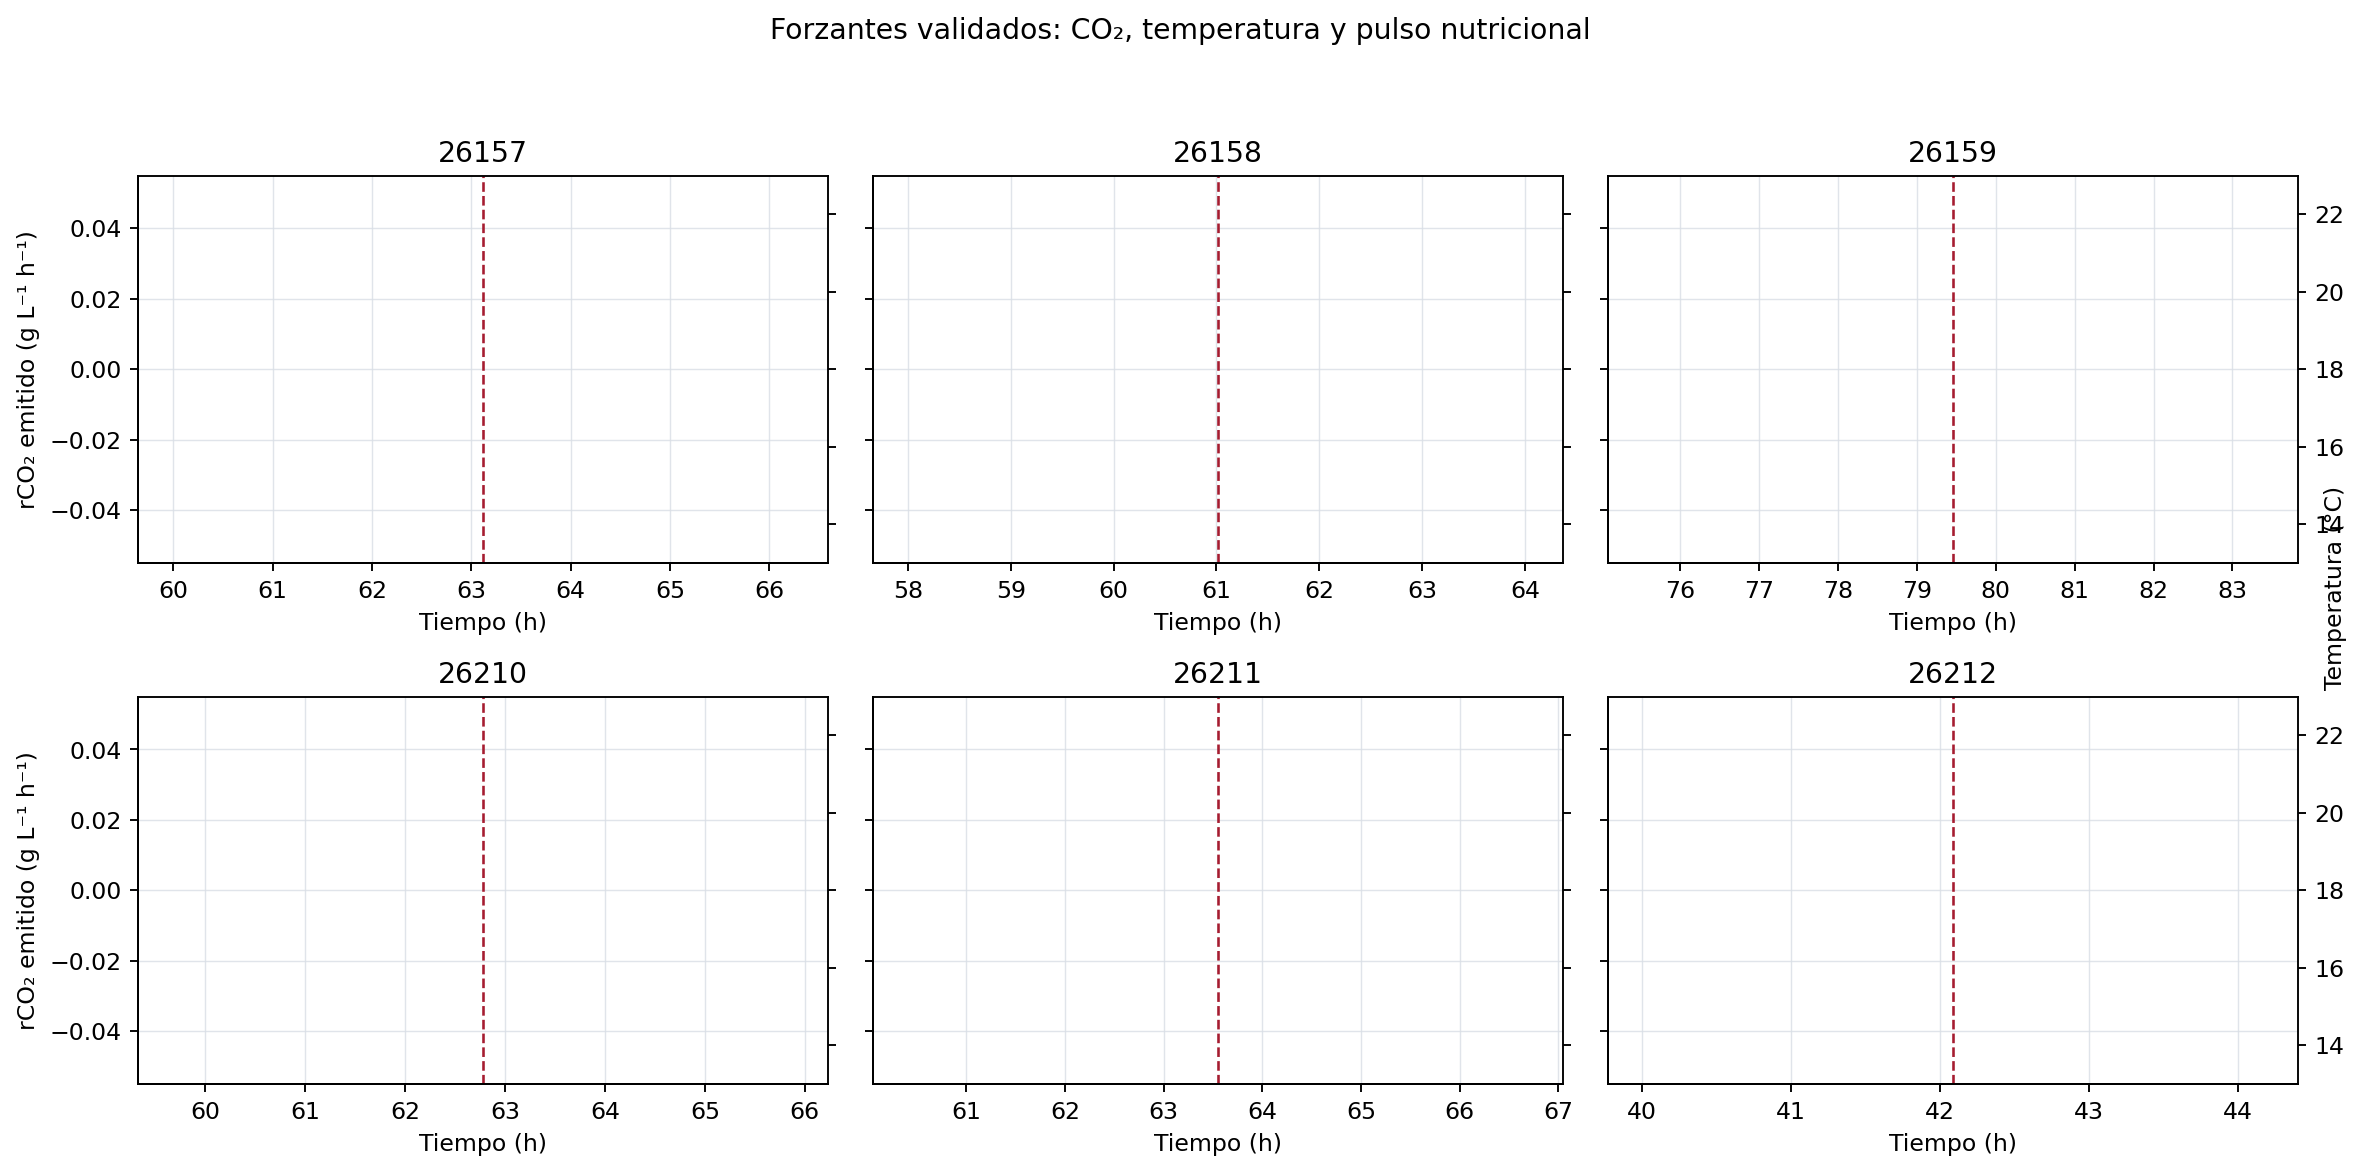

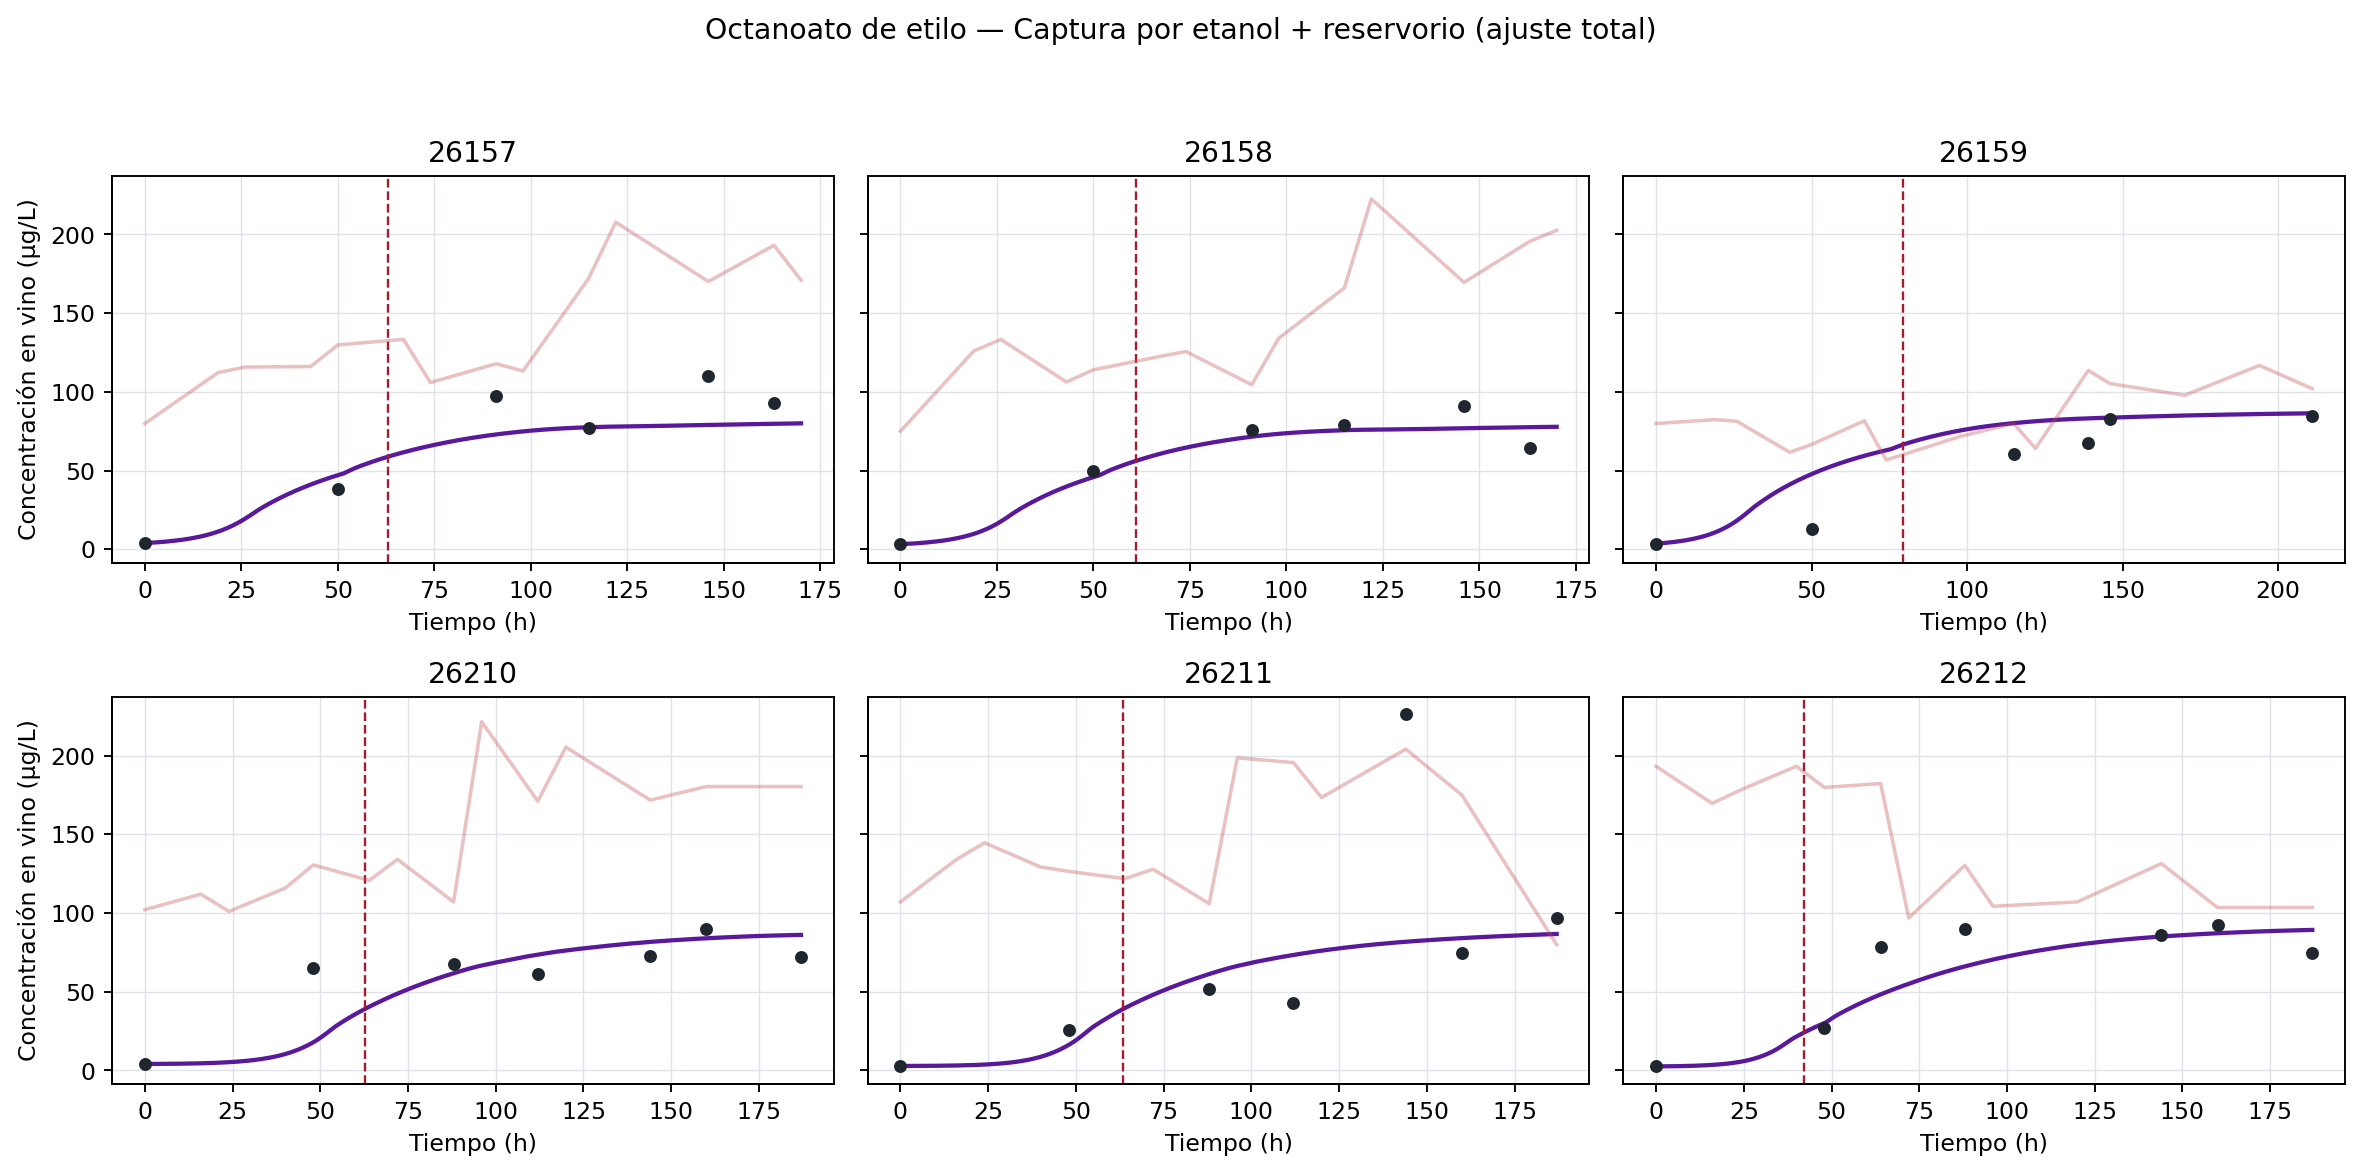

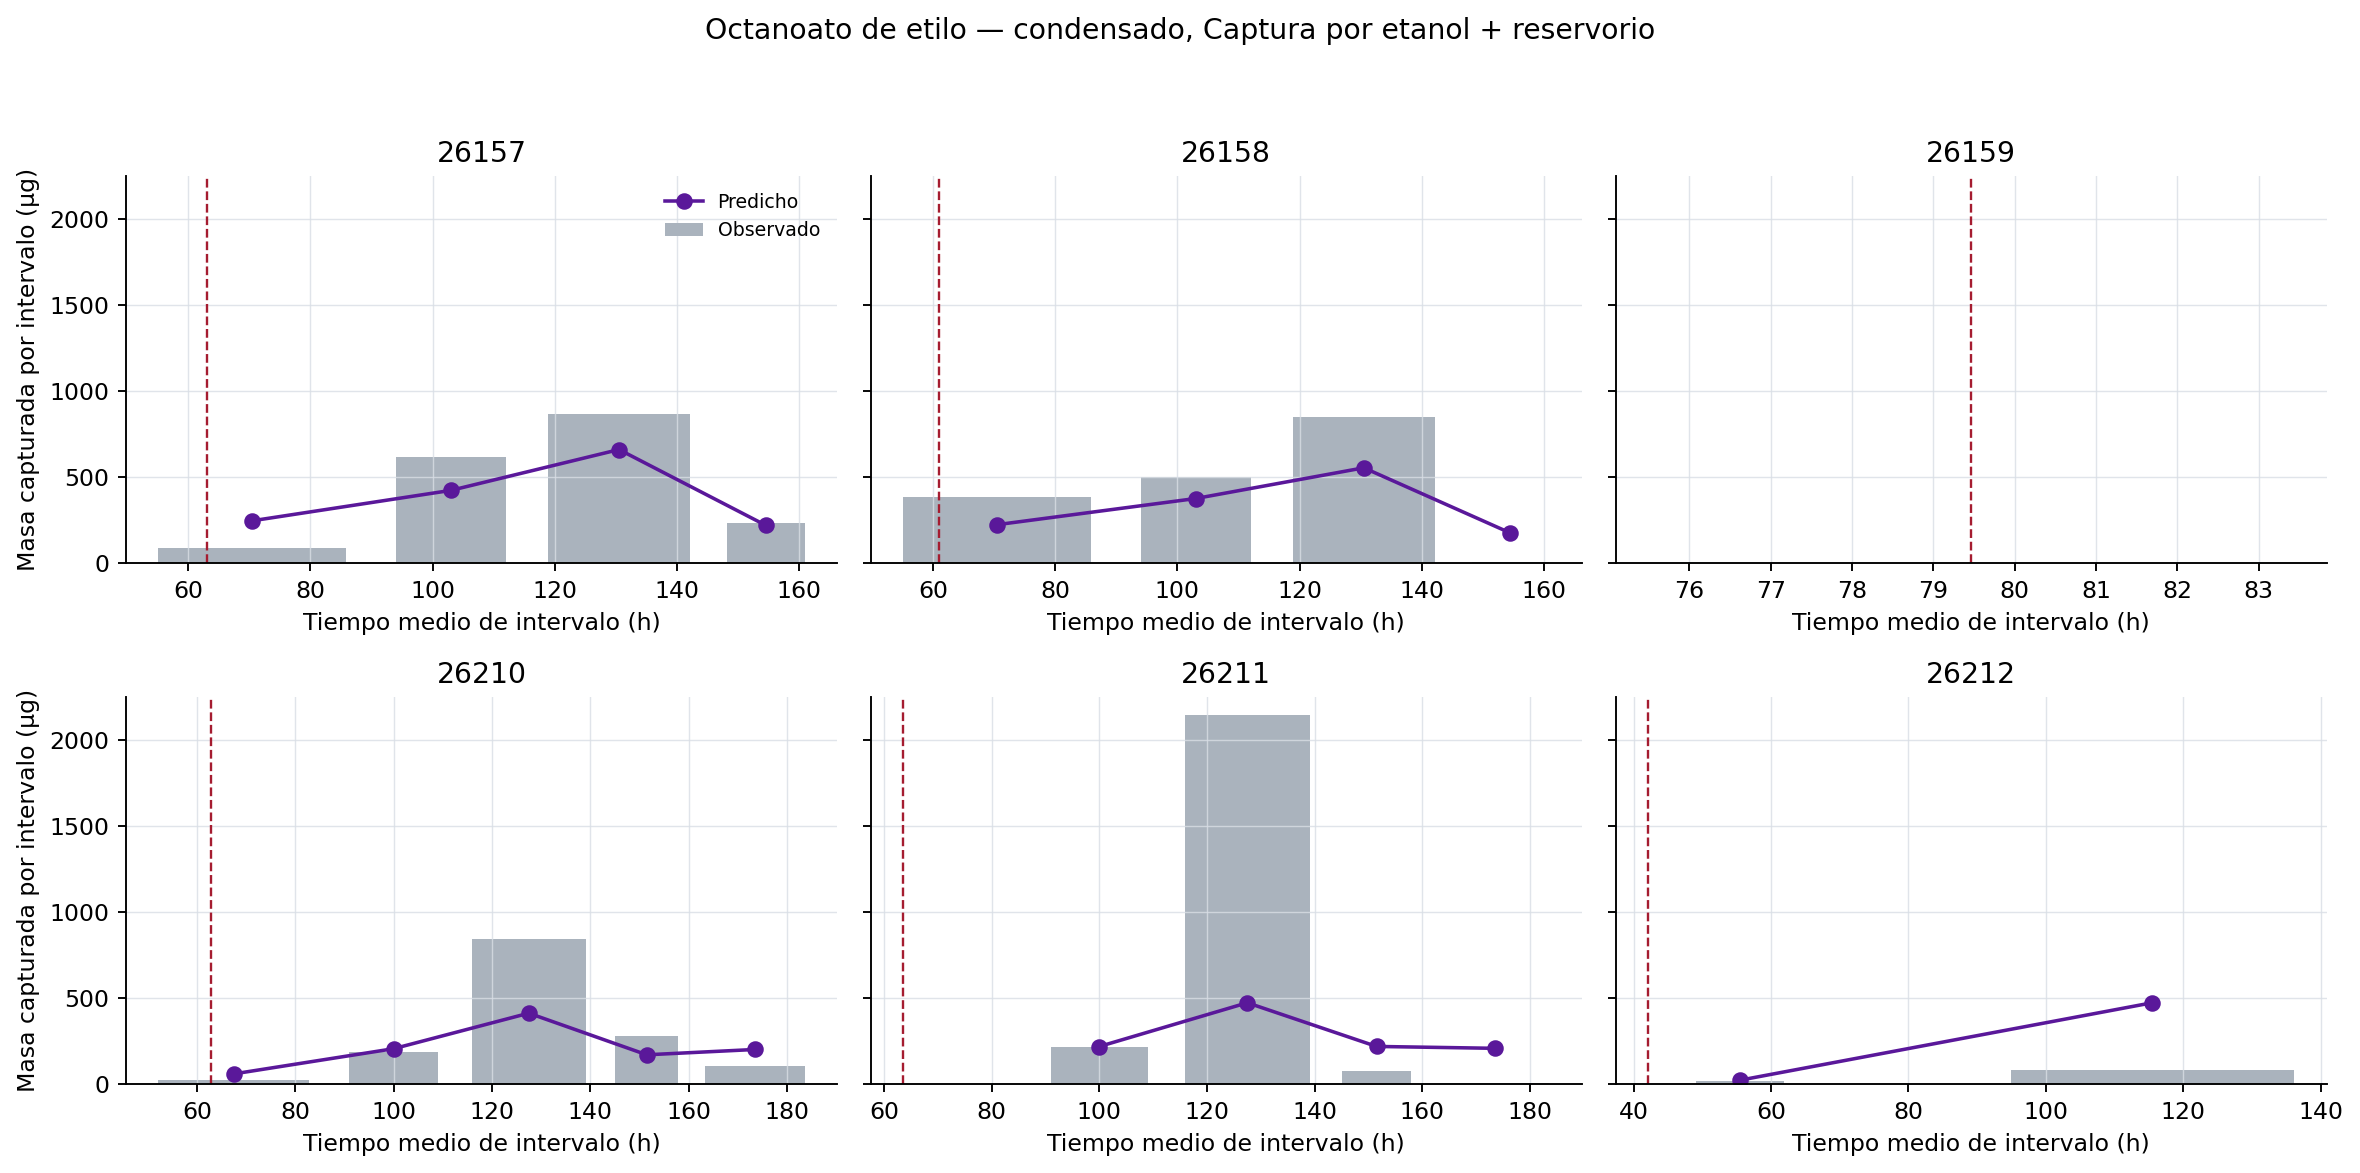

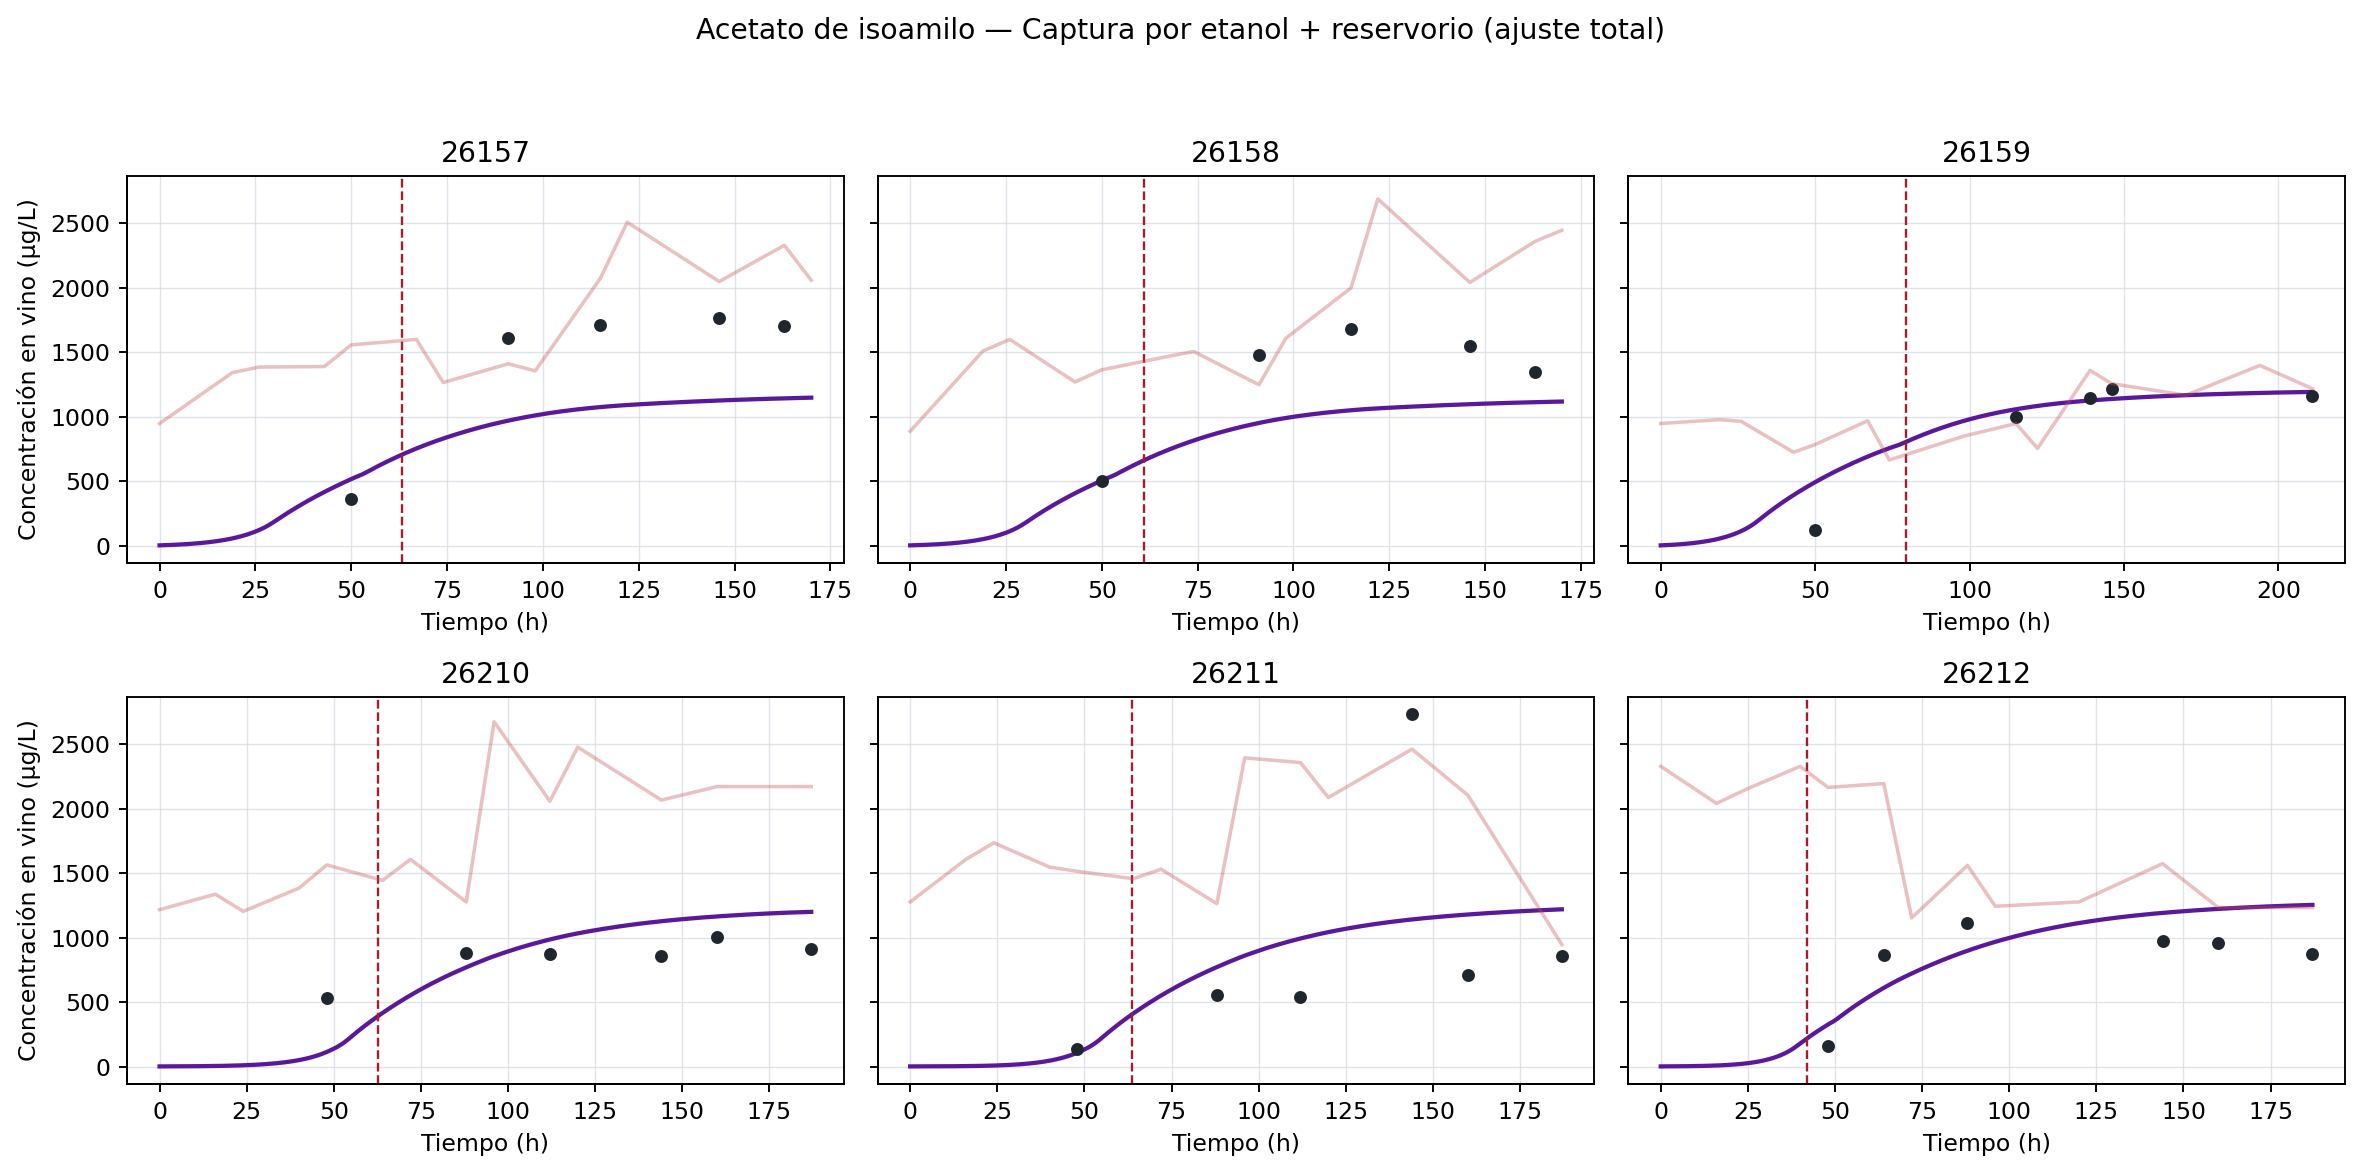

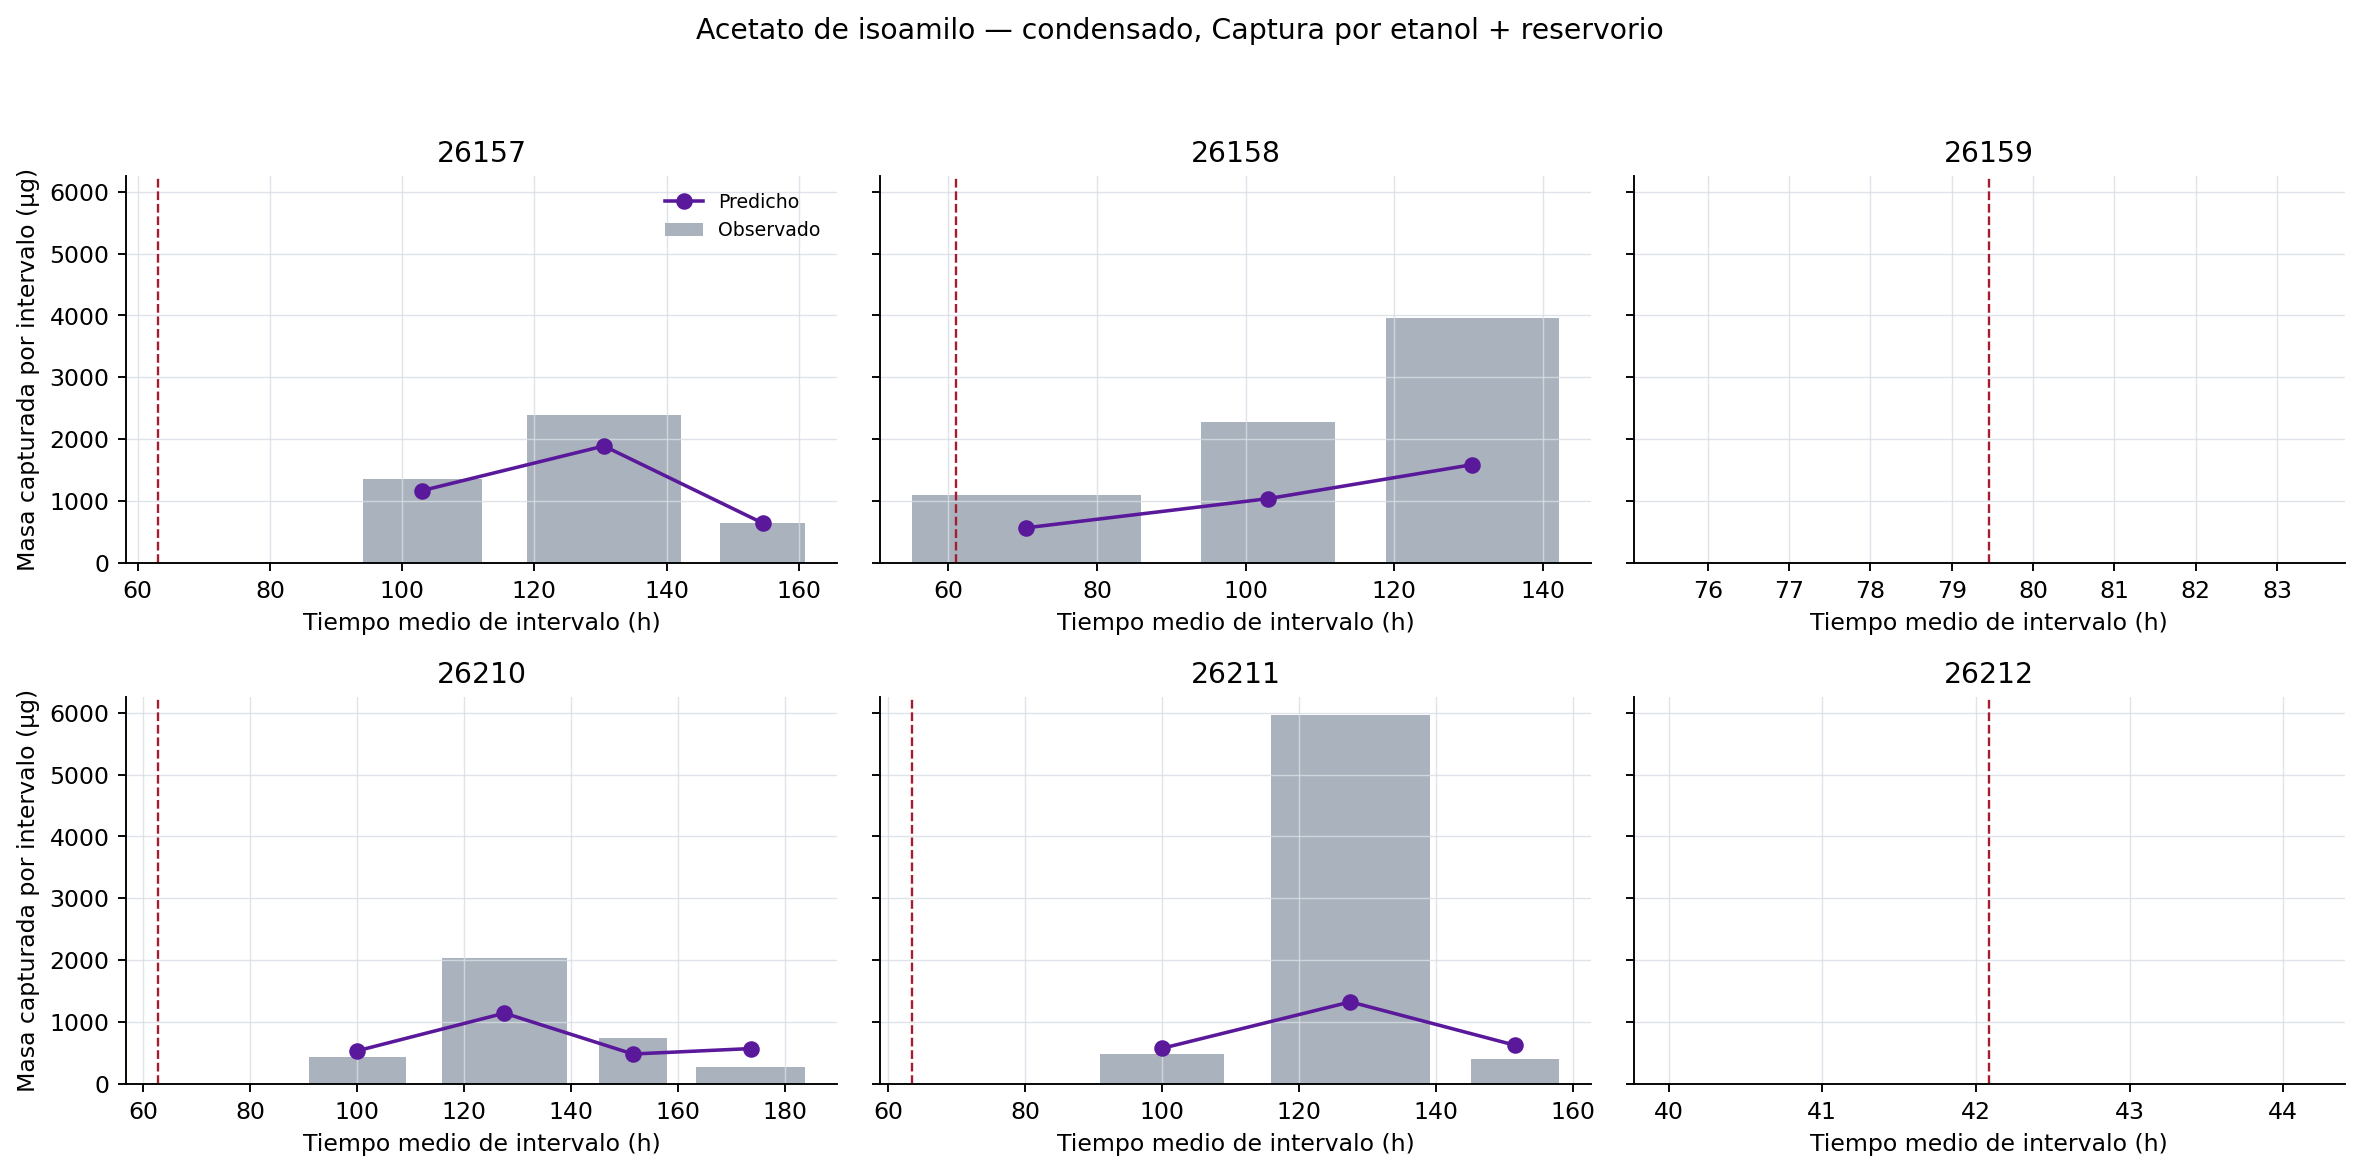

In [4]:
display(Image(filename=analysis.FIGURE_DIR / '03_rco2_temperature_pulse_drivers.png'))
for species in analysis.decision.ethanol.capture.base.SPECIES_LABELS:
    display(Image(filename=analysis.FIGURE_DIR / f'04_liquid_{species}.png'))
    display(Image(filename=analysis.FIGURE_DIR / f'05_condensate_{species}.png'))

## Parámetros finales

In [5]:
display(result['parameters'].round(6))
display(result['fit_validation'].round(6))

,fit_scope,species,model_variant,parameter,estimate,lower_bound,upper_bound,active_bound,std_log_local
0,all_data,ethyl_octanoate,fitted_capture_efficiency,formation_growth_ug_per_g_sugar,0.527444,0.00010,10000.0,False,4.418154
1,all_data,ethyl_octanoate,fitted_capture_efficiency,formation_stationary_ug_per_g_sugar,0.816639,0.00010,10000.0,False,0.411123
2,all_data,ethyl_octanoate,fitted_capture_efficiency,capture_efficiency_fraction,0.039071,0.00001,1.0,False,1.907566
3,all_data,isoamyl_acetate,fitted_capture_efficiency,formation_growth_ug_per_g_sugar,2.859199,0.00010,10000.0,False,6.521697
4,all_data,isoamyl_acetate,fitted_capture_efficiency,formation_stationary_ug_per_g_sugar,10.527472,0.00010,10000.0,False,0.348932
5,all_data,isoamyl_acetate,fitted_capture_efficiency,capture_efficiency_fraction,0.019397,0.00001,1.0,False,2.074829
6,all_data,ethyl_octanoate,ethanol_dependent_capture_efficiency,formation_growth_ug_per_g_sugar,0.998034,0.00010,10000.0,False,2.037576
7,all_data,ethyl_octanoate,ethanol_dependent_capture_efficiency,formation_stationary_ug_per_g_sugar,0.754466,0.00010,10000.0,False,0.386149
8,all_data,ethyl_octanoate,ethanol_dependent_capture_efficiency,capture_efficiency_fraction,0.039611,0.00001,1.0,False,1.326489
9,all_data,ethyl_octanoate,ethanol_dependent_capture_efficiency,ethanol_capture_multiplier_per_10_g_l,2.451183,0.20000,5.0,False,0.607259


,fit_scope,model_variant,species,success,converged_multistarts,robust_cost,weighted_sse,n_residuals_including_prior,active_bound_fraction,covariance_finite,covariance_condition,maximum_relative_mass_balance_error
0,all_data,fitted_capture_efficiency,ethyl_octanoate,True,6,192.969980,932.624848,69,0.0,True,599.630402,0.0
1,all_data,fitted_capture_efficiency,isoamyl_acetate,True,6,167.958684,532.577682,69,0.0,True,1133.322228,0.0
2,all_data,ethanol_dependent_capture_efficiency,ethyl_octanoate,True,6,166.303365,654.195582,70,0.0,True,176.204155,0.0
3,all_data,ethanol_dependent_capture_efficiency,isoamyl_acetate,True,6,152.150694,407.743714,70,0.0,True,417.385012,0.0
4,all_data,ethanol_capture_plus_line_reservoir,ethyl_octanoate,True,6,166.053328,646.089854,71,0.0,True,3348.975635,0.0
5,all_data,ethanol_capture_plus_line_reservoir,isoamyl_acetate,True,6,151.952606,404.155433,71,0.0,True,1988.423396,0.0


## Separación producción–transferencia–captura

In [6]:
selected = result['gate']['selected_model'] or result['gate']['diagnostic_best_model']
display(result['mass_balance'].query('model_variant == @selected').round(4))

,model_variant,species,experiment_id,terminal_time_h,initial_liquid_inventory_ug,biological_production_ug,terminal_liquid_inventory_ug,terminal_line_inventory_ug,emitted_or_drained_ug,recovered_condensate_ug,emitted_but_unrecovered_ug,mass_closure_error_ug,volatile_fraction_of_available_mass,effective_recovery_fraction_of_drained_mass
0,ethanol_capture_plus_line_reservoir,ethyl_octanoate,26157,170.0,918.8240,27212.4557,18407.3798,62.0423,9661.8577,1621.7812,8040.0765,-0.0,0.3435,0.1679
1,ethanol_capture_plus_line_reservoir,ethyl_octanoate,26158,170.0,756.9365,26439.0086,17904.9273,59.4138,9231.6040,1385.4760,7846.1280,-0.0,0.3394,0.1501
2,ethanol_capture_plus_line_reservoir,ethyl_octanoate,26159,211.0,844.1882,27339.0628,19877.3560,19.5356,8286.3594,1483.6709,6802.6886,0.0,0.2940,0.1790
3,ethanol_capture_plus_line_reservoir,ethyl_octanoate,26210,187.0,939.0647,27412.7449,19796.6290,54.4549,8500.7256,1048.0190,7452.7067,-0.0,0.2998,0.1233
4,ethanol_capture_plus_line_reservoir,ethyl_octanoate,26211,187.0,648.9652,27948.7467,19932.6497,32.2469,8632.8153,1176.1583,7456.6570,0.0,0.3019,0.1362
5,ethanol_capture_plus_line_reservoir,ethyl_octanoate,26212,187.0,586.1552,27658.9093,20523.4452,26.4053,7695.2140,825.9285,6869.2855,-0.0,0.2724,0.1073
6,ethanol_capture_plus_line_reservoir,isoamyl_acetate,26157,170.0,575.0000,328534.7953,263838.5349,580.2380,64691.0224,4543.3221,60147.7003,0.0,0.1966,0.0702
7,ethanol_capture_plus_line_reservoir,isoamyl_acetate,26158,170.0,575.0000,318864.0852,256898.4869,549.6876,61990.9107,3880.5050,58110.4057,-0.0,0.1941,0.0626
8,ethanol_capture_plus_line_reservoir,isoamyl_acetate,26159,211.0,575.0000,329287.7755,274067.0865,179.0366,55616.6524,4077.1769,51539.4756,0.0,0.1686,0.0733
9,ethanol_capture_plus_line_reservoir,isoamyl_acetate,26210,187.0,575.0000,328409.1545,276037.4184,487.5247,52459.2114,2875.2763,49583.9351,0.0,0.1595,0.0548


## Takeaways

- `PASS` indica transferibilidad interna bajo todos los guardrails; no convierte η o τ en parámetros físicos medidos.
- `NO_VALID_MODEL` indica que la variabilidad de condensado y/o la inestabilidad paramétrica impiden una conclusión predictiva con estos datos.
- La confirmación mínima mide simultáneamente vino, gas de salida, volumen y %EtOH de cada MIX, recuperación de estándar gaseoso y duplicados.

In [7]:
assert result['gate']['verdict'] in {'PASS', 'NO_VALID_MODEL'}
assert len(result['figures']) == 8
assert result['fit_validation']['maximum_relative_mass_balance_error'].max() <= 1e-8
print('Notebook ejecutado sin errores; figuras:', len(result['figures']))

Notebook ejecutado sin errores; figuras: 8
